# Synthèse de vidéos de personnes parlant à partir d’un fichier audio et d’une image du visage
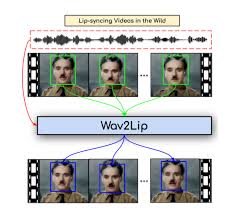

**Dataset après le prétraitement**

### 🎞️ Visualisation des Frames d'une Vidéo et Lecture de l'Audio

Ce script a pour objectif de **visualiser quelques images extraites d'une vidéo (frames)** et de **lire l'audio associé** à cette même vidéo.

#### Étapes réalisées :
-  Recherche dans un dossier contenant les **frames (images)** extraites d’une vidéo et un fichier **audio (.wav)** correspondant.
- Sélection et affichage des **3 premières images** (frames) de la vidéo sur une seule ligne.
- Recherche et lecture du **fichier audio** (s’il est présent) à l’aide du widget `IPython.display.Audio`.

####  Exemple de structure du dossier :

/lrs2_preprocessed/5535415699068794046/00001/
├── 000001.jpg
├── 000002.jpg
├── 000003.jpg
├── audio.wav

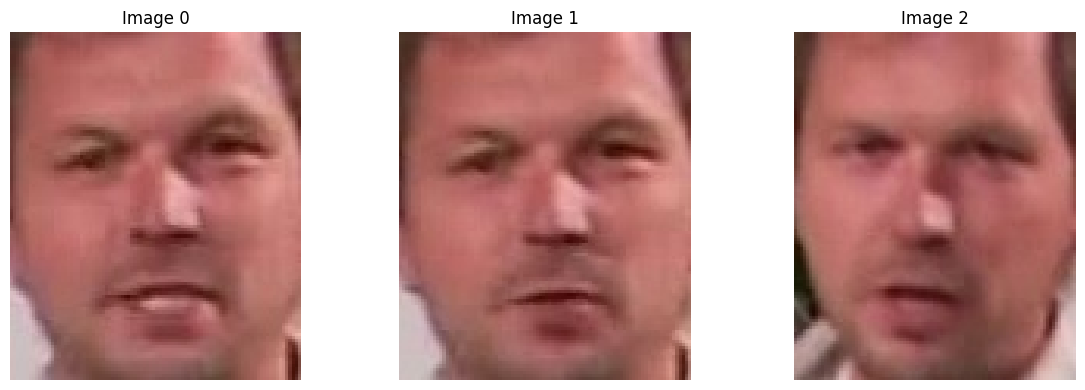

Lecture de l'audio :


In [ ]:
import os
from IPython.display import Audio
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Chemin vers le dossier contenant les images et l'audio
base_path = "/content/drive/MyDrive/Wav2Lip/lrs2_preprocessed/5535415699068794046/00001"

# Lister tous les fichiers dans le dossier
files = sorted(os.listdir(base_path))

# Sélectionner les 3 premières images (par ordre alphabétique ou numérique)
image_files = [f for f in files if f.endswith('.jpg')][:3]

# Afficher les images sur une seule ligne
plt.figure(figsize=(12, 4))
for idx, img_name in enumerate(image_files):
    img_path = os.path.join(base_path, img_name)
    img = mpimg.imread(img_path)
    plt.subplot(1, 3, idx + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Image {idx}")
plt.tight_layout()
plt.show()

# Chercher un fichier audio (supposé .wav)
audio_files = [f for f in files if f.endswith('.wav')]
if audio_files:
    print("Lecture de l'audio :")
    display(Audio(filename=os.path.join(base_path, audio_files[0])))
else:
    print("Aucun fichier audio trouvé.")


Ce dossier contient :
-  Les **images** représentant les **frames extraites** d’une vidéo.
- Un fichier **audio.wav** correspondant à l’extrait audio de cette séquence vidéo.

**Analyse des Sous-Dossiers du Dataset LRS2 Prétraité**

Ce script permet de **parcourir les sous-dossiers** d’un répertoire donné contenant des données prétraitées (frames vidéo et audio) et de **résumer le contenu de chaque sous-dossier**.

#### Fonctionnalités principales :
- Liste tous les sous-dossiers présents dans le dossier de base.
- Compte le nombre de **frames d’images (.jpg)** dans chaque sous-dossier.
- Vérifie la présence d’un fichier **audio (.wav)** dans chaque sous-dossier.
- Affiche un tableau récapitulatif indiquant, pour chaque dossier :
  - Le nom du sous-dossier,
  - Le nombre d’images (frames),
  - La présence ou non d’un fichier audio.

Cette exploration est utile pour s’assurer que les données sont bien organisées et complètes avant d’entraîner un modèle de synchronisation labiale ou autre analyse multimédia.

In [ ]:
import os

# Chemin de base
base_path = "/content/drive/MyDrive/Wav2Lip/lrs2_preprocessed/5535415699068794046"

# Lister les sous-dossiers
subfolders = sorted(os.listdir(base_path))

# Créer un tableau récapitulatif
print(f"{'Dossier':<10} | {'# Frames':<8} | {'Audio'}")
print("-" * 30)

for folder in subfolders:
    folder_path = os.path.join(base_path, folder)
    if os.path.isdir(folder_path):
        files = os.listdir(folder_path)
        num_frames = len([f for f in files if f.endswith('.jpg')])
        has_audio = any(f.endswith('.wav') for f in files)
        print(f"{folder:<10} | {num_frames:<8} | {'Oui' if has_audio else 'Non'}")


Dossier    | # Frames | Audio
------------------------------
00001      | 35       | Oui
00002      | 63       | Oui
00003      | 43       | Oui
00004      | 65       | Oui
00006      | 68       | Oui
00007      | 71       | Oui
00008      | 24       | Oui
00009      | 39       | Oui
00011      | 40       | Oui
00013      | 70       | Oui
00014      | 65       | Oui


Le tableau montre que chaque sous-dossier contient à la fois un fichier audio et un nombre significatif de frames d’images. Cette répartition homogène indique que les éléments multimédias sont bien équilibrés dans le dataset :

Présence constante de l’audio dans tous les dossiers garantit que chaque séquence dispose des deux modalités nécessaires (audio + vidéo) pour la synchronisation labiale.

Nombre de frames relativement proche entre les différents dossiers (entre 24 et 71 frames) montre une distribution cohérente de la durée des séquences vidéo, sans déséquilibre marqué vers des séquences trop courtes ou trop longues.

Cet équilibre est important pour assurer un apprentissage stable des modèles, en évitant que certains exemples soient sous-représentés ou surreprésentés, ce qui pourrait biaiser la performance.

 **Montage de Google Drive dans Google**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!git clone https://github.com/Rudrabha/Wav2Lip.git



Cloning into 'Wav2Lip'...
remote: Enumerating objects: 406, done.
remote: Counting objects: 100% (1/1), done.
remote: Total 406 (delta 0), reused 0 (delta 0), pack-reused 405 (from 3)
Receiving objects: 100% (406/406), 546.59 KiB | 18.22 MiB/s, done.
Resolving deltas: 100% (225/225), done.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Cette commande git clone permet de télécharger localement une copie complète du dépôt GitHub Wav2Lip depuis l’URL spécifiée. Le projet Wav2Lip est une méthode avancée de synchronisation labiale, qui génère des mouvements de lèvres réalistes à partir d’un fichier audio, souvent utilisée pour des applications de deepfake ou d’animation faciale.

**Écriture d’un fichier requirements.txt corrigé pour Wav2Lip**

In [ ]:
corrected_requirements = """
librosa==0.8.1
numpy==1.23.5
opencv-contrib-python>=4.5.5.64
tqdm==4.66.1
numba==0.57.1
"""
with open("/content/drive/MyDrive/Wav2Lip/requirements.txt", "w") as f:
    f.write(corrected_requirements)


Ce script crée ou remplace le fichier requirements.txt dans le dossier Wav2Lip sur Google Drive, en y inscrivant une liste précise de dépendances Python avec leurs versions spécifiques. Cela garantit que l’environnement d’exécution utilise des versions compatibles des bibliothèques nécessaires, telles que librosa, numpy, opencv-contrib-python, tqdm et numba.

**Installation spécifique de PyTorch et torchvision avec support CUDA 11.8**

In [ ]:
!pip install torch==2.0.1 torchvision==0.15.2 --index-url https://download.pytorch.org/whl/cu118


Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 GB 442.3 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 82.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.3/63.3 MB 12.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.3/132.3 kB 14.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lit: filename=lit-15.0.7-py3-none-any.whl size=89991 sha256=ccad2b6db67c3c26b7a12b0e739e4da1bdd98817a72858f2f6cce7670f07b948
  Stored in directory: /root/.cache/pip/wheels/fc/5d/45/34fe9945d5e45e261134e72284395be36c2d4828af38e2b0fe
Successfully built lit
  Attempting uninstall: triton
    Found existing installation: triton 3.1.0
    Uninstalling triton-3.1.0:
      Successfully uninstalled triton-3.1.0
  Attempting uninstall: torch
    Found existing installation: torch 2.5.1+cu124
    Uninstalling torch-2.5.1+cu124:
      Successfully uninstalled to

Cette commande installe les versions précises de PyTorch (2.0.1) et torchvision (0.15.2) compatibles avec CUDA 11.8, en utilisant l’index officiel de PyTorch pour garantir l’installation des binaires GPU optimisés.

**Installation des dépendances du projet Wav2Lip**

In [ ]:
!cd /content/drive/MyDrive/Wav2Lip && pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.8/203.8 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.3/78.3 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 53.1 MB/s eta 0:00:00
  Attempting uninstall: tqdm
    Found existing installation: tqdm 4.67.1
    Uninstalling tqdm-4.67.1:
      Successfully uninstalled tqdm-4.67.1
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvm

Cette commande change le répertoire actif vers le dossier du projet Wav2Lip situé dans Google Drive, puis installe toutes les bibliothèques listées dans le fichier requirements.txt pour préparer l’environnement de travail.

 **Téléchargement du modèle pré-entraîné SFD pour la détection de visages**

In [ ]:
!wget "https://www.adrianbulat.com/downloads/python-fan/s3fd-619a316812.pth" -O "/content/drive/MyDrive/Wav2Lip/face_detection/detection/sfd/s3fd.pth"

--2025-05-19 17:02:06--  https://www.adrianbulat.com/downloads/python-fan/s3fd-619a316812.pth
Resolving www.adrianbulat.com (www.adrianbulat.com)... 45.136.29.207
Connecting to www.adrianbulat.com (www.adrianbulat.com)|45.136.29.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 89843225 (86M) [application/octet-stream]
Saving to: ‘/content/drive/MyDrive/Wav2Lip/face_detection/detection/sfd/s3fd.pth’

/content/drive/MyDr 100%[===================>]  85.68M  19.7MB/s    in 5.5s    

2025-05-19 17:02:12 (15.7 MB/s) - ‘/content/drive/MyDrive/Wav2Lip/face_detection/detection/sfd/s3fd.pth’ saved [89843225/89843225]



Cette commande télécharge le fichier du modèle pré-entraîné s3fd.pth depuis le site officiel d’Adrian Bulat et le sauvegarde dans le répertoire spécifique du projet Wav2Lip, afin de l’utiliser pour la détection de visages dans les vidéos.



**Changer le répertoire de travail vers le dossier Wav2Lip**

In [ ]:
!cd /content/drive/MyDrive/Wav2Lip

In [ ]:
!ls /content/drive/MyDrive/Wav2Lip

app.py			mvlrs_v1
audio.py		preprocess.py
checkpoints		__pycache__
color_syncnet_train.py	README.md
evaluation		requirements.txt
examples		results
expert_checkpoints	temp
face_detection		temp_audio_a52c9574-7527-4fe5-86b4-f44b6eabc006.wav
filelists		temp_audio_c6160db2-3321-4cc1-9fbf-ecf4a2755c13.wav
hparams.py		temp_video_c6160db2-3321-4cc1-9fbf-ecf4a2755c13.mp4
hq_wav2lip_train.py	test
inference.py		wav2lip_checkpoints
lrs2_preprocessed	wav2lip_train.py
models


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!cd /content/drive/MyDrive/Wav2Lip  && pip install torch==2.0.1 torchvision==0.15.2 --index-url https://download.pytorch.org/whl/cu118
!cd /content/drive/MyDrive/Wav2Lip && pip install -r requirements.txt
!pip install gradio




Mounted at /content/drive
Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 GB 570.4 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 89.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.3/63.3 MB 11.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.3/132.3 kB 11.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lit: filename=lit-15.0.7-py3-none-any.whl size=89990 sha256=cd623c7a95067a657be6efc38c432f0e08b87cf1e756ca506f3948204f9615b4
  Stored in directory: /root/.cache/pip/wheels/fc/5d/45/34fe9945d5e45e261134e72284395be36c2d4828af38e2b0fe
Successfully built lit
  Attempting uninstall: triton
    Found existing installation: triton 3.2.0
    Uninstalling triton-3.2.0:
      Successfully uninstalled triton-3.2.0
  Attempting uninstall: torch
    Found existing installation: torch 2.6.0+cu124
    Uninstalling torch-2.6.0+cu124:
      Suc

In [ ]:
!python /content/drive/MyDrive/Wav2Lip/app.py

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://04c52e58000a89e7f2.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --en

**Application de Synchronisation Labiale avec Wav2Lip via Gradio**


In [ ]:
import os
import subprocess
import uuid
import shutil
import numpy as np
from scipy.io import wavfile
import gradio as gr

# Répertoires
WAV2LIP_DIR = "/content/drive/MyDrive/Wav2Lip"
CHECKPOINT_PATH = os.path.join(WAV2LIP_DIR, "checkpoints/wav2lip_gan.pth")
RESULTS_DIR = os.path.join(WAV2LIP_DIR, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

def lip_sync_with_upload(face_media_path, audio_file):
    uid = str(uuid.uuid4())
    input_video_path = os.path.join(WAV2LIP_DIR, f"temp_video_{uid}.mp4")
    input_audio_path = os.path.join(WAV2LIP_DIR, f"temp_audio_{uid}.wav")
    output_video_path = os.path.join(RESULTS_DIR, f"result_voice_{uid}.mp4")

    if face_media_path.endswith((".jpg", ".jpeg", ".png")):
        temp_image_path = os.path.join(WAV2LIP_DIR, f"temp_image_{uid}.png")
        shutil.copy(face_media_path, temp_image_path)
        cmd = f"ffmpeg -y -loop 1 -i {temp_image_path} -t 5 -vf scale=512:512 -c:v libx264 -pix_fmt yuv420p {input_video_path}"
        subprocess.call(cmd, shell=True)
        os.remove(temp_image_path)
    else:
        shutil.copy(face_media_path, input_video_path)

    if isinstance(audio_file, tuple):
        sample_rate, audio_data = audio_file
    else:
        import librosa
        audio_data, sample_rate = librosa.load(audio_file, sr=None)
        audio_data = (audio_data * 32767).astype(np.int16)

    if not isinstance(audio_data, np.ndarray):
        audio_data = np.array(audio_data, dtype=np.int16)

    wavfile.write(input_audio_path, sample_rate, audio_data)

    command = f"""
    cd {WAV2LIP_DIR} && python inference.py \\
    --checkpoint_path "{CHECKPOINT_PATH}" \\
    --audio "{input_audio_path}" \\
    --face "{input_video_path}" \\
    --outfile "{output_video_path}"
    """
    subprocess.call(command, shell=True)
    os.remove(input_video_path)
    os.remove(input_audio_path)

    return output_video_path

# Interface Gradio
with gr.Blocks(title="Wav2Lip Sync App") as interface:
    gr.HTML("""
    <style>
        body {
            background-color: #f0f2f5;
            font-family: 'Segoe UI', sans-serif;
        }
        .gr-button {
            background: linear-gradient(to right, #1d976c, #93f9b9);
            color: white !important;
            font-weight: bold;
            border-radius: 8px;
            padding: 10px 20px;
            font-size: 16px;
            border: none;
        }
        .gr-button:hover {
            background: linear-gradient(to right, #11998e, #38ef7d);
        }
        h2 {
            color: #2e8b57;
        }
    </style>
    """)

    gr.Markdown("## 🎬 **Synchronisation Labiale Professionnelle avec Wav2Lip**")

    with gr.Row():
        with gr.Column(scale=1):
            media_input = gr.File(label="📹 Image ou Vidéo", file_types=[".jpg", ".png", ".mp4"], type="filepath")
            audio_input = gr.Audio(label="🎵 Audio (.wav)", type="filepath")

            image_preview = gr.Image(label="🖼️ Aperçu de l'image", visible=False, height=180)
            video_preview = gr.Video(label="🎞️ Aperçu de la vidéo", visible=False, height=300, width=300)

            def preview_media(file_path):
                if file_path.endswith((".jpg", ".png", ".jpeg")):
                    return gr.update(visible=True, value=file_path), gr.update(visible=False)
                else:
                    return gr.update(visible=False), gr.update(visible=True, value=file_path)

            media_input.change(fn=preview_media, inputs=media_input, outputs=[image_preview, video_preview])

            btn = gr.Button("🚀 Lancer la Synchronisation", elem_classes="gr-button")

        with gr.Column(scale=1):
            output_video = gr.Video(label="📤 Vidéo Générée", height=360, width=700)

        btn.click(fn=lip_sync_with_upload, inputs=[media_input, audio_input], outputs=output_video)

interface.launch(share=True)



**os**, **shutil**: pour manipuler les fichiers et dossiers.

**subprocess** : pour exécuter des commandes système (comme ffmpeg ou python inference.py).

**uuid** : pour générer des identifiants uniques temporaires.

**numpy, scipy.io.wavfile** : pour traiter les fichiers audio.

**gradio** : pour créer l’interface web.

**Définition des chemins principaux**

Définit les chemins vers :

Le dossier du projet Wav2Lip

Le modèle pré-entraîné (.pth)

Le dossier de sortie pour les vidéos générées

**Fonction lip_sync_with_upload(face_media_path, audio_file)**

###  But :
Prend une **image ou une vidéo** et un **fichier audio**, puis génère une **vidéo synchronisée** avec les mouvements des lèvres à l’aide du modèle Wav2Lip.

---

### Étapes de la fonction `lip_sync_with_upload` :

- **Génère un identifiant unique** (`uid`) pour nommer les fichiers temporaires de manière unique.

- **Si l’entrée est une image** (`.jpg`, `.png`, `.jpeg`) :
  - Elle est **convertie en une courte vidéo de 5 secondes** à l’aide de `ffmpeg`.
  - Cette vidéo sert de base pour synchroniser les lèvres.

- **Si l’entrée est une vidéo** (`.mp4`) :
  - Elle est **copiée directement** sans transformation.

-  **Le fichier audio est traité** :
  - S’il est fourni sous forme de chemin, il est **chargé avec `librosa`**.
  - Il est ensuite **converti en format `.wav`** (16 bits) avec `scipy.wavfile`.

- **Exécution du modèle Wav2Lip** :
  - Lancement du script `inference.py` avec les bons chemins (`--audio`, `--face`, `--outfile`).
  - Génération de la **vidéo finale synchronisée**.

- **Nettoyage** :
  - Suppression des **fichiers temporaires** (image/vidéo/audio intermédiaires).

- **Retourne la vidéo générée** :
  - Le chemin de la vidéo synchronisée est retourné pour affichage dans l'interface.


**Exécution de l'inférence Wav2Lip pour générer une vidéo synchronisée**

**ckpt, video_input, audio_input, output_video** : chemins vers le modèle pré-entraîné, la vidéo d'entrée, l'audio d'entrée, et la vidéo de sortie.

**!cd /content/drive/MyDrive/Wav2Lip** : se déplace dans le dossier du projet Wav2Lip pour exécuter le script **inference.py**.

python inference.py --checkpoint_path ... : exécute le script d'inférence en utilisant :

--checkpoint_path : le modèle Wav2Lip entraîné (fichier .pth),

--face : la vidéo ou image contenant le visage à animer,

--audio : l’audio à synchroniser avec le mouvement des lèvres,

--outfile : chemin de la vidéo générée contenant la synchronisation labiale.


In [ ]:
import subprocess

ckpt = "/content/drive/MyDrive/Wav2Lip/checkpoints/wav2lip_gan.pth"
video_input = "/content/drive/MyDrive/Wav2Lip/test/input_video.mp4"
audio_input = "/content/drive/MyDrive/Wav2Lip/test/input_audio.wav"
output_video = "/content/drive/MyDrive/Wav2Lip/result_video.mp4"
!cd /content/drive/MyDrive/Wav2Lip && python inference.py --checkpoint_path "{ckpt}" --face "{video_input}" --audio "{audio_input}" --outfile "{output_video}"


Using cuda for inference.
Reading video frames...
Number of frames available for inference: 210
(80, 353)
Length of mel chunks: 128
  0% 0/1 [00:00<?, ?it/s]
  0% 0/8 [00:00<?, ?it/s]
 12% 1/8 [00:17<02:00, 17.15s/it]
 25% 2/8 [00:18<00:47,  7.84s/it]
 38% 3/8 [00:19<00:24,  4.88s/it]
 50% 4/8 [00:21<00:13,  3.49s/it]
 62% 5/8 [00:22<00:08,  2.75s/it]
 75% 6/8 [00:24<00:04,  2.34s/it]
 88% 7/8 [00:25<00:02,  2.09s/it]
100% 8/8 [00:27<00:00,  3.38s/it]
Load checkpoint from: /content/drive/MyDrive/Wav2Lip/checkpoints/wav2lip_gan.pth
Model loaded
100% 1/1 [00:37<00:00, 37.54s/it]
ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libblura

**Affichage des 5 premières images (frames) d’une vidéo input**

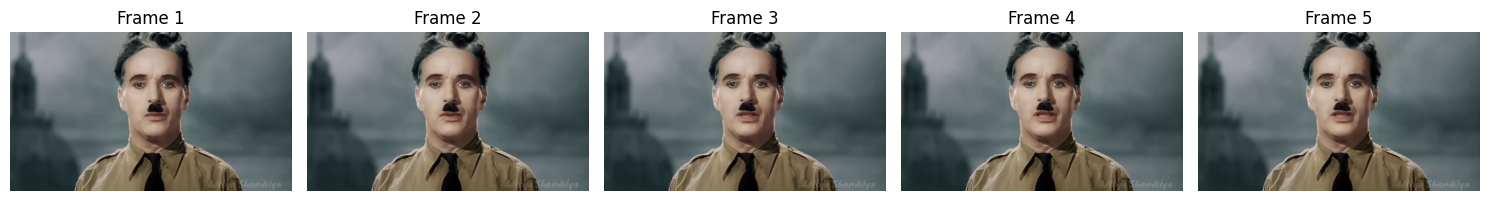

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Ouvrir la vidéo
cap = cv2.VideoCapture(video_input)

plt.figure(figsize=(15, 5))

# Lire et afficher les 5 premières frames
for i in range(5):
    ret, frame = cap.read()
    if ret:
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        plt.subplot(1, 5, i + 1)
        plt.imshow(frame)
        plt.axis('off')
        plt.title(f"Frame {i+1}")
    else:
        print(f"Impossible de lire la frame {i+1}")
        break

cap.release()
plt.tight_layout()
plt.show()


In [ ]:
from IPython.display import Audio

# Affichage du lecteur audio
Audio(audio_input)


In [ ]:
import base64
from IPython.display import HTML

def show_video(video_path, width=640):
    video_file = open(video_path, "rb").read()
    video_url = f"data:video/mp4;base64,{base64.b64encode(video_file).decode()}"
    return HTML(f"""<video width="{width}" controls><source src="{video_url}" type="video/mp4"></video>""")

show_video('/content/drive/MyDrive/Wav2Lip/result_video.mp4')